In [2]:
import numpy as np
import pandas as pd
import os

test_df = pd.read_csv('../data/plant_pathology_2020/test.csv')
train_df = pd.read_csv('../data/plant_pathology_2020/train.csv')


In [3]:
train_df.head()

,image_id,healthy,multiple_diseases,rust,scab
0,Train_0,0,0,0,1
1,Train_1,0,1,0,0
2,Train_2,1,0,0,0
3,Train_3,0,0,1,0
4,Train_4,1,0,0,0


In [4]:
test_df.head()

,image_id
0,Test_0
1,Test_1
2,Test_2
3,Test_3
4,Test_4


In [5]:
train_df.shape, test_df.shape

((1821, 5), (1821, 1))

#### 이미지의 절대 경로를 DataFrame에 추가하고 개별 컬럼별 0/1 값을 구분하여 클래스 라벨로 생성

In [ ]:
train_df['path'] = '/Users/songbeom/PythonWorkSpace/CNN_project/data/plant_pathology_2020/images/' + train_df['image_id'] + '.jpg'

train_df['path'][0] # 이미지 절대 경로 만들어 주기

'/Users/songbeom/PythonWorkSpace/CNN_project/data/plant_pathology_2020/images/Train_0.jpg'

(1365, 2048, 3)


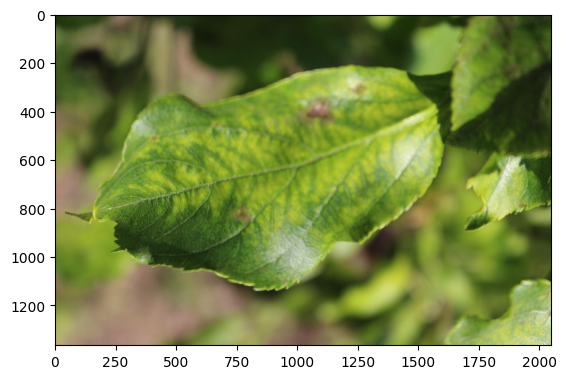

In [16]:
import cv2
import matplotlib.pyplot as plt

image = cv2.cvtColor(cv2.imread(train_df['path'][0]), cv2.COLOR_BGR2RGB)
print(image.shape)
plt.imshow(image)

In [17]:
train_df.head()

,image_id,healthy,multiple_diseases,rust,scab,path
0,Train_0,0,0,0,1,/Users/songbeom/PythonWorkSpace/CNN_project/da...
1,Train_1,0,1,0,0,/Users/songbeom/PythonWorkSpace/CNN_project/da...
2,Train_2,1,0,0,0,/Users/songbeom/PythonWorkSpace/CNN_project/da...
3,Train_3,0,0,1,0,/Users/songbeom/PythonWorkSpace/CNN_project/da...
4,Train_4,1,0,0,0,/Users/songbeom/PythonWorkSpace/CNN_project/da...


In [25]:
def get_label(x):
    if x['healthy'] == 1:
        return 'healthy'
    elif x['multiple_diseases'] == 1:
        return 'multiple_diseases'
    elif x['rust'] == 1:
        return 'rust'
    elif x['scab'] == 1:
        return 'scab'

train_df['label'] = train_df.apply(lambda x: get_label(x), axis=1)

train_df.head()

,image_id,healthy,multiple_diseases,rust,scab,path,label
0,Train_0,0,0,0,1,/Users/songbeom/PythonWorkSpace/CNN_project/da...,scab
1,Train_1,0,1,0,0,/Users/songbeom/PythonWorkSpace/CNN_project/da...,multiple_diseases
2,Train_2,1,0,0,0,/Users/songbeom/PythonWorkSpace/CNN_project/da...,healthy
3,Train_3,0,0,1,0,/Users/songbeom/PythonWorkSpace/CNN_project/da...,rust
4,Train_4,1,0,0,0,/Users/songbeom/PythonWorkSpace/CNN_project/da...,healthy


In [26]:
train_df['label'].value_counts()

label
rust                 622
scab                 592
healthy              516
multiple_diseases     91
Name: count, dtype: int64

In [27]:
# label 명을 target 값으로 매핑
label_mapping = {'healthy' : 0, 'multiple_diseases' : 1, 'rust': 2, 'scab' : 3}


train_df['target'] = train_df['label'].map(label_mapping)

In [28]:
train_df['target'].value_counts()

target
2    622
3    592
0    516
1     91
Name: count, dtype: int64

In [29]:
train_df.head()

,image_id,healthy,multiple_diseases,rust,scab,path,label,target
0,Train_0,0,0,0,1,/Users/songbeom/PythonWorkSpace/CNN_project/da...,scab,3
1,Train_1,0,1,0,0,/Users/songbeom/PythonWorkSpace/CNN_project/da...,multiple_diseases,1
2,Train_2,1,0,0,0,/Users/songbeom/PythonWorkSpace/CNN_project/da...,healthy,0
3,Train_3,0,0,1,0,/Users/songbeom/PythonWorkSpace/CNN_project/da...,rust,2
4,Train_4,1,0,0,0,/Users/songbeom/PythonWorkSpace/CNN_project/da...,healthy,0


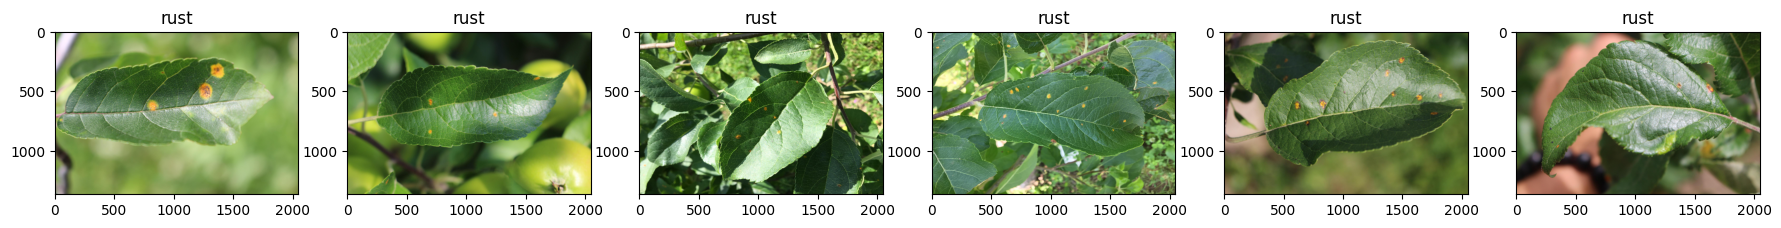

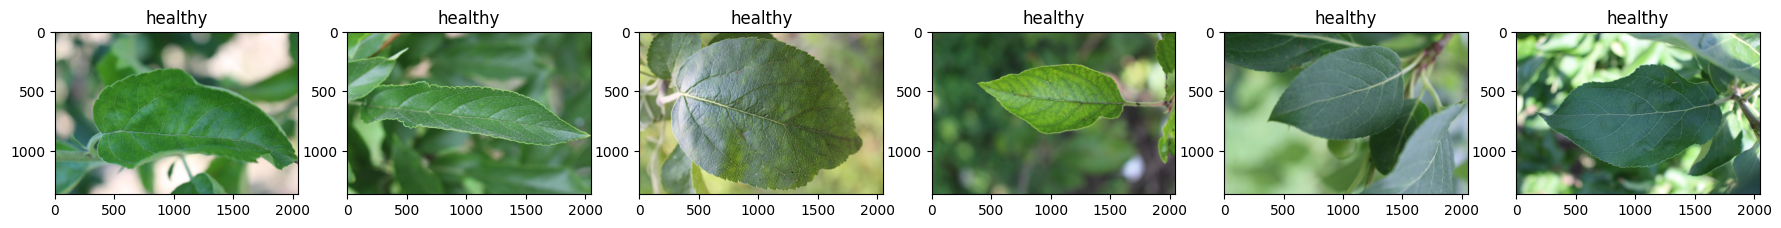

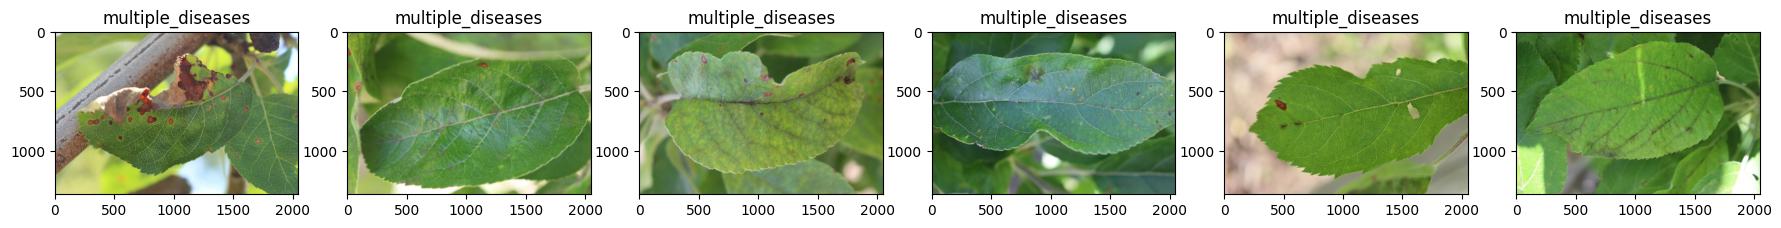

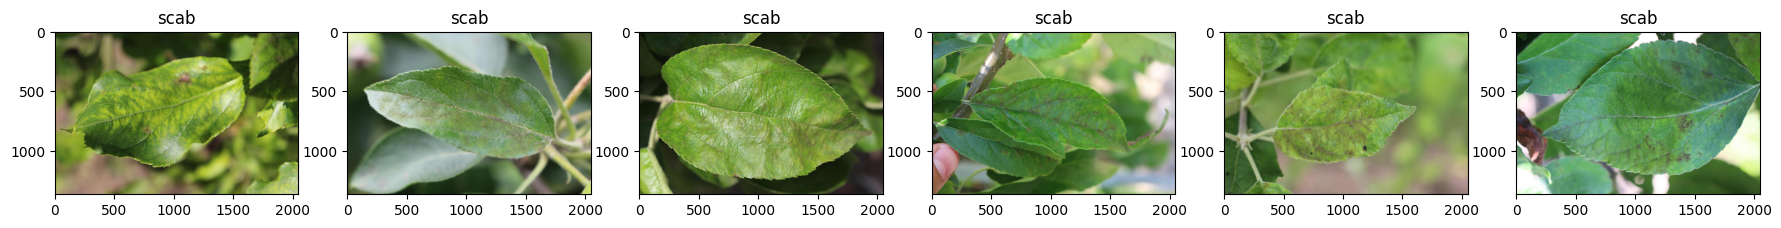

In [35]:
def show_grid_images(image_path_list, augmentor=None, ncols=4, title=None):
    figure, axs = plt.subplots(figsize=(22,4), nrows=1, ncols=ncols)
    for i in range(ncols):
        image = cv2.cvtColor(cv2.imread(image_path_list[i]), cv2.COLOR_BGR2RGB)
        if augmentor is not None:
            image = augmentor(image=image)['image']
        axs[i].imshow(image)
        axs[i].set_title(title)

# healthy' : 0, 'multiple_diseases' : 1, 'rust': 2, 'scab' : 3
rust_image_list = train_df[train_df['label'] == 'rust']['path'].iloc[:6].tolist()
healthy_image_list = train_df[train_df['label'] == 'healthy']['path'].iloc[:6].tolist()
multiple_diseases_image_list = train_df[train_df['label'] == 'multiple_diseases']['path'].iloc[:6].tolist()
scab_image_list = train_df[train_df['label'] == 'scab']['path'].iloc[:6].tolist()


show_grid_images(rust_image_list, ncols=6, title='rust')
show_grid_images(healthy_image_list, ncols=6, title='healthy')
show_grid_images(multiple_diseases_image_list, ncols=6, title='multiple_diseases')
show_grid_images(scab_image_list, ncols=6, title='scab')
